In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
path = Path.cwd()
data_dir = path.parent / "data"
EMBEDDED_DATA = data_dir / "embeddings"
NAME = "indic_bert_v1.npy"
PATH = EMBEDDED_DATA / NAME

# Load the data
X = np.load(PATH)

In [3]:
X.shape

(4000, 768)

In [5]:
from sklearn.decomposition import PCA

pca = PCA()
X_reduced = pca.fit_transform(X)

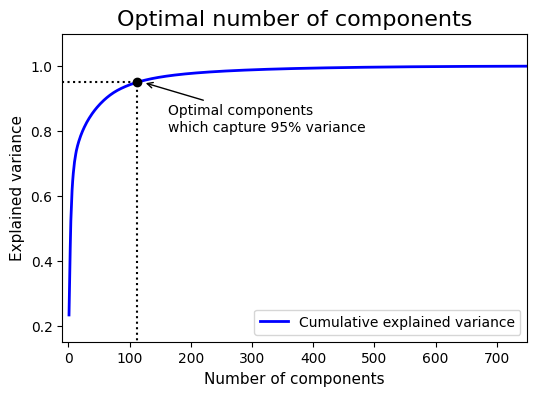

In [6]:
cumsum_var_ratio = np.cumsum(pca.explained_variance_ratio_)
opti_compo = np.argmax(cumsum_var_ratio >= 0.95) + 1

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), cumsum_var_ratio, "b", linewidth=2, label="Cumulative explained variance")
plt.plot([opti_compo , opti_compo] , [0 , 0.95] , "k:")
plt.plot([-10 , opti_compo], [0.95 , 0.95], "k:")
plt.plot(opti_compo , 0.95 , "ko")
plt.annotate("Optimal components \nwhich capture 95% variance",
             xy=(opti_compo + 10, 0.95),
             xytext=(opti_compo + 50, 0.80),
             arrowprops=dict(arrowstyle="->")
             )
plt.axis([-10 , 750 , 0.15 , 1.1])
plt.xlabel("Number of components" , fontsize=11)
plt.ylabel("Explained variance", fontsize=11)
plt.title("Optimal number of components", fontsize=16)
plt.legend(loc="lower right")
plt.show()

In [7]:
from sklearn.decomposition import PCA

# we get the optimal dimensions for the data
pca = PCA(n_components=opti_compo, random_state=42)
X_reduced = pca.fit_transform(X)

In [5]:
reduced_data = data_dir / "reduced"
reduced_data.mkdir(parents=True, exist_ok=True)

In [6]:
SAVING_FILE_PATH = reduced_data / "reduced_v1.npy"

if not os.path.exists(SAVING_FILE_PATH):
    np.save(SAVING_FILE_PATH , X_reduced)